<a href="https://colab.research.google.com/github/Anushadhirde/Urban-Heat-Island-Change-Detection/blob/main/Compute_lst_stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
STEP: Compute LST mean and standard deviation for each year/season scene.

WHY: The UHI classification thresholds (Strong/Weak/No UHI/Cooling) are defined
RELATIVE to each scene's own mean/std, not a fixed temperature. This script
computes those stats and saves them to a CSV so the next script (threshold
classification) can just look them up instead of recomputing.

WHERE IT READS FROM: your stacked files from stack_bands_loop.py, since band 1
in every stacked file is LST (based on band_order = DYNAMIC_VARS + STATIC_VARS,
and DYNAMIC_VARS[0] = "LST").

BEFORE YOU RUN:
- Confirm STACKED_FOLDER matches OUTPUT_FOLDER from your stacking script.
- Confirm YEARS/SEASONS match what actually got stacked successfully.
"""

import os
import rasterio
import numpy as np
import csv

# ---- EDIT THESE to match your setup ----
STACKED_FOLDER = "/content/drive/MyDrive/DATASET/STACKED"
OUTPUT_CSV = "/content/drive/MyDrive/DATASET/lst_scene_stats.csv"
YEARS = list(range(2017, 2026))
SEASONS = ["Summer", "Winter"]

LST_BAND_INDEX = 1  # band 1 = LST, per the band_order from the stacking script


def compute_lst_stats(path):
    with rasterio.open(path) as src:
        lst = src.read(LST_BAND_INDEX).astype("float64")
        nodata = src.nodata

    if nodata is not None and not np.isnan(nodata):
        valid = lst[lst != nodata]
    else:
        # nodata is unset OR is itself NaN (common case) -> filter NaNs directly
        valid = lst[~np.isnan(lst)]

    if valid.size == 0:
        return None

    return {
        "mean": float(np.mean(valid)),
        "std": float(np.std(valid)),
        "min": float(np.min(valid)),
        "max": float(np.max(valid)),
        "valid_pixel_count": int(valid.size),
        "total_pixel_count": int(lst.size),
    }


def main():
    rows = []
    for year in YEARS:
        for season in SEASONS:
            path = os.path.join(STACKED_FOLDER, f"stack_{year}_{season}.tif")
            if not os.path.exists(path):
                print(f"  MISSING: {path} — skipping")
                continue

            stats = compute_lst_stats(path)
            if stats is None:
                print(f"  NO VALID PIXELS: {path} — skipping")
                continue

            stats.update({"year": year, "season": season})
            rows.append(stats)
            print(
                f"{year} {season}: mean={stats['mean']:.2f}, std={stats['std']:.2f}, "
                f"valid pixels={stats['valid_pixel_count']}/{stats['total_pixel_count']}"
            )

    if not rows:
        print("No scenes processed — check STACKED_FOLDER and filenames.")
        return

    fieldnames = ["year", "season", "mean", "std", "min", "max",
                  "valid_pixel_count", "total_pixel_count"]
    with open(OUTPUT_CSV, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"\nDone. Saved stats for {len(rows)} scenes to {OUTPUT_CSV}")


if __name__ == "__main__":
    main()

2017 Summer: mean=50.72, std=4.27, valid pixels=11005619/21126080
2017 Winter: mean=31.12, std=3.04, valid pixels=11005618/21126080
2018 Summer: mean=48.48, std=4.04, valid pixels=11005619/21126080
2018 Winter: mean=32.80, std=3.47, valid pixels=11005618/21126080
2019 Summer: mean=53.73, std=4.63, valid pixels=11005619/21126080
2019 Winter: mean=30.77, std=3.07, valid pixels=11005413/21126080
2020 Summer: mean=45.98, std=4.23, valid pixels=11005619/21126080
2020 Winter: mean=30.38, std=2.92, valid pixels=11005116/21126080
2021 Summer: mean=47.22, std=4.23, valid pixels=11005619/21126080
2021 Winter: mean=30.00, std=2.80, valid pixels=11005542/21126080
2022 Summer: mean=45.80, std=3.60, valid pixels=11005619/21126080
2022 Winter: mean=31.14, std=3.07, valid pixels=11005601/21126080
2023 Summer: mean=46.60, std=4.97, valid pixels=11005619/21126080
2023 Winter: mean=32.46, std=3.24, valid pixels=11005568/21126080
2024 Summer: mean=44.64, std=4.14, valid pixels=11005619/21126080
2024 Winte

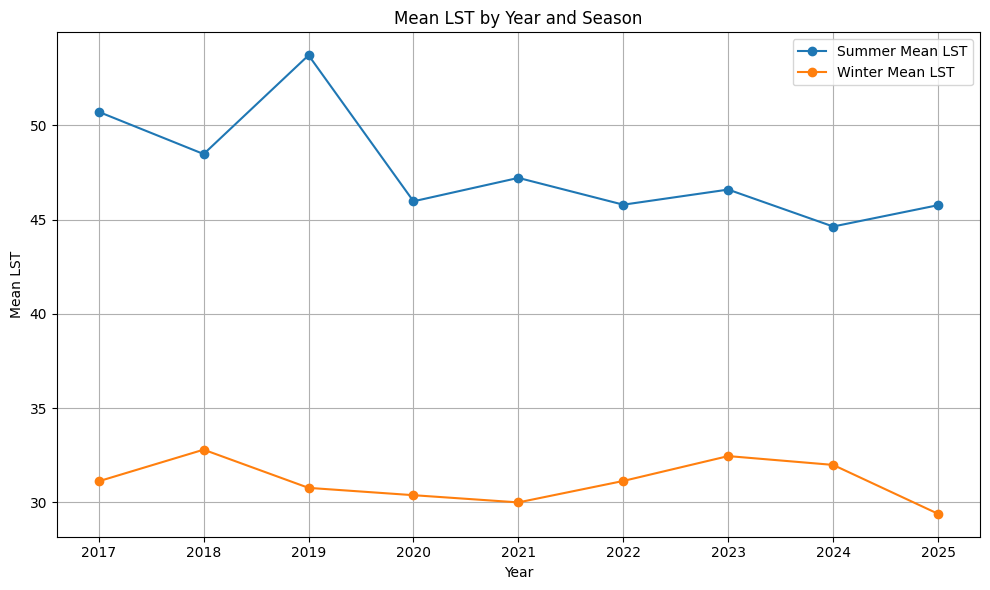

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file created in the previous step
try:
    df = pd.read_csv(OUTPUT_CSV)
except FileNotFoundError:
    print(f"Error: The file {OUTPUT_CSV} was not found. Please ensure the previous cell ran successfully.")
    exit()

# Filter data for Summer and Winter
summer_df = df[df['season'] == 'Summer']
winter_df = df[df['season'] == 'Winter']

# Create the plot
plt.figure(figsize=(10, 6))

plt.plot(summer_df['year'], summer_df['mean'], marker='o', label='Summer Mean LST')
plt.plot(winter_df['year'], winter_df['mean'], marker='o', label='Winter Mean LST')

plt.title('Mean LST by Year and Season')
plt.xlabel('Year')
plt.ylabel('Mean LST')
plt.xticks(df['year'].unique())
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()